In [1]:
import os
import json
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.ticker as ticker
import torchvision

In [2]:
LEARNING_RATE = 0.001
BATCH_SIZE = 64
EPOCHS = 500
SEED = 42

In [18]:
TARGET_DIR = f"ASAI_SVRG_paper/outputs/CIFAR10_CNN3-1_01/{LEARNING_RATE}/{BATCH_SIZE}/{EPOCHS}/{SEED}"

def load_result(optimizer):
    file_path = f"{TARGET_DIR}/{optimizer}/result.json"
    if not os.path.exists(file_path):
        print(file_path)
        return [], [], [], [], []
    
    with open(file_path, "r") as f:
        data = json.load(f)

    if optimizer == 'NFG_SVRG' or optimizer == 'ASAI_SVRG':
        return data["x"], data["train_loss"], data["train_acc"], data["test_loss"], data["test_acc"], data['norm']

    else:
        return data["x"], data["train_loss"], data["train_acc"], data["test_loss"], data["test_acc"]



SGD_x, SGD_train_loss_history, SGD_train_acc_history, SGD_test_loss_history, SGD_test_acc_history = load_result("SGD")
SVRG_x, SVRG_train_loss_history, SVRG_train_acc_history, SVRG_test_loss_history, SVRG_test_acc_history = load_result("SVRG")
NFG_SVRG_x, NFG_SVRG_train_loss_history, NFG_SVRG_train_acc_history, NFG_SVRG_test_loss_history, NFG_SVRG_test_acc_history, NFG_SVRG_norm_history = load_result("NFG_SVRG")
ASAI_SVRG_x, ASAI_SVRG_train_loss_history, ASAI_SVRG_train_acc_history, ASAI_SVRG_test_loss_history, ASAI_SVRG_test_acc_history, ASAI_SVRG_norm_history = load_result("ASAI_SVRG")
Polyak_SVRG_x, Polyak_SVRG_train_loss_history, Polyak_SVRG_train_acc_history, Polyak_SVRG_test_loss_history, Polyak_SVRG_test_acc_history = load_result("Polyak_SVRG")
_, GD_train_loss_history, GD_train_acc_history, GD_test_loss_history, GD_test_acc_history = load_result("GD")

ASAI_SVRG_paper/outputs/CIFAR10_CNN3-1_01/0.001/64/500/42/Polyak_SVRG/result.json
ASAI_SVRG_paper/outputs/CIFAR10_CNN3-1_01/0.001/64/500/42/GD/result.json


In [ ]:
TARGET_DIR = f"outputs/CIFAR10_CNN/norm/{LEARNING_RATE}/{BATCH_SIZE}/{EPOCHS}/{SEED}"

def load_result(optimizer_name):
    file_path = f"{TARGET_DIR}/{optimizer_name}/result.json"
    if not os.path.exists(file_path):
        print(f"Warning: {file_path} が見つかりません。空のリストを返します。")
        return [], []
    
    with open(file_path, "r") as f:
        data = json.load(f)
    
    return data["norm"]

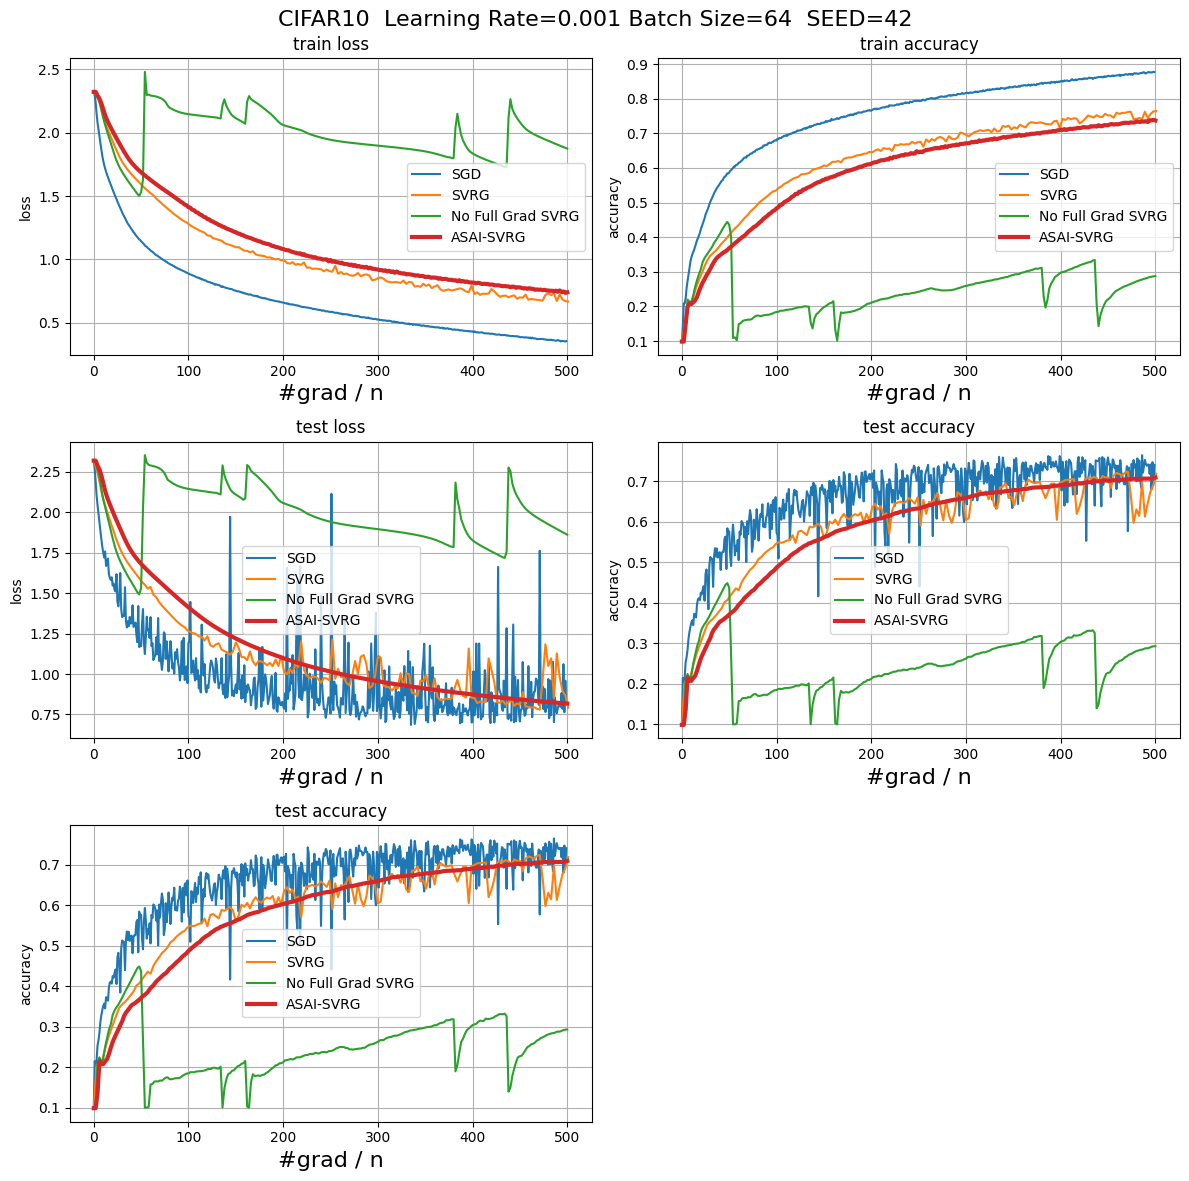

In [28]:
fig = plt.figure(figsize = (12, 12))
fig.suptitle(f"CIFAR10  Learning Rate={LEARNING_RATE} Batch Size={BATCH_SIZE}  SEED={SEED}",fontsize=16)
ax = fig.add_subplot(3, 2, 1)
ax.plot(SGD_x, SGD_train_loss_history, label = "SGD")
ax.plot(SVRG_x, SVRG_train_loss_history, label = "SVRG")
ax.plot(NFG_SVRG_x, NFG_SVRG_train_loss_history, label = "No Full Grad SVRG")
ax.plot(ASAI_SVRG_x, ASAI_SVRG_train_loss_history, label = "ASAI-SVRG", linewidth = 3)
ax.set_xlabel("#grad / n", fontsize=16)
ax.set_ylabel("loss")
ax.set_title("train loss")
ax.grid()
ax.legend()

ax = fig.add_subplot(3, 2, 2)
ax.plot(SGD_x, SGD_train_acc_history, label = "SGD")
ax.plot(SVRG_x, SVRG_train_acc_history, label = "SVRG")
ax.plot(NFG_SVRG_x, NFG_SVRG_train_acc_history, label = "No Full Grad SVRG")
ax.plot(ASAI_SVRG_x, ASAI_SVRG_train_acc_history, label = "ASAI-SVRG", linewidth = 3)
ax.set_xlabel("#grad / n", fontsize=16)
ax.set_ylabel("accuracy")
ax.set_title("train accuracy")
ax.grid()
ax.legend()

ax = fig.add_subplot(3, 2, 3)
ax.plot(SGD_x, SGD_test_loss_history, label = "SGD")
ax.plot(SVRG_x, SVRG_test_loss_history, label = "SVRG")
ax.plot(NFG_SVRG_x, NFG_SVRG_test_loss_history, label = "No Full Grad SVRG")
ax.plot(ASAI_SVRG_x, ASAI_SVRG_test_loss_history, label = "ASAI-SVRG", linewidth = 3)
ax.set_xlabel("#grad / n", fontsize=16)
ax.set_ylabel("loss")
ax.set_title("test loss")
ax.grid()
ax.legend()

ax = fig.add_subplot(3, 2, 4)
ax.plot(SGD_x, SGD_test_acc_history, label = "SGD")
ax.plot(SVRG_x, SVRG_test_acc_history, label = "SVRG")
ax.plot(NFG_SVRG_x, NFG_SVRG_test_acc_history, label = "No Full Grad SVRG")
ax.plot(ASAI_SVRG_x, ASAI_SVRG_test_acc_history, label = "ASAI-SVRG", linewidth = 3)
ax.set_xlabel("#grad / n", fontsize=16)
ax.set_ylabel("accuracy")
ax.set_title("test accuracy")
ax.grid()
ax.legend()

ax = fig.add_subplot(3, 2, 5)
ax.plot(SGD_x, SGD_test_acc_history, label = "SGD")
ax.plot(SVRG_x, SVRG_test_acc_history, label = "SVRG")
ax.plot(NFG_SVRG_x, NFG_SVRG_test_acc_history, label = "No Full Grad SVRG")
ax.plot(ASAI_SVRG_x, ASAI_SVRG_test_acc_history, label = "ASAI-SVRG", linewidth = 3)
ax.set_xlabel("#grad / n", fontsize=16)
ax.set_ylabel("accuracy")
ax.set_title("test accuracy")
ax.grid()
ax.legend()

plt.tight_layout()
plt.show()

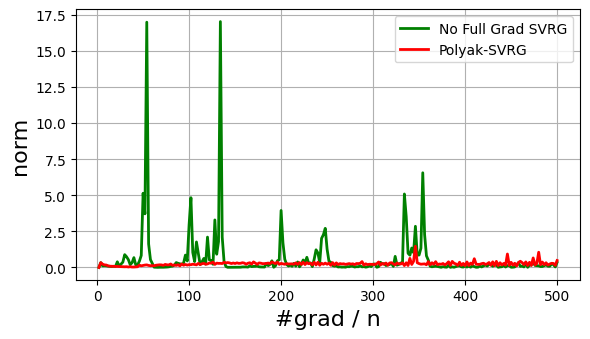

In [7]:
fig = plt.figure(figsize = (6, 3.5))
ax = fig.add_subplot()

ax.plot(NFG_SVRG_x , NFG_SVRG_norm_history, label = "No Full Grad SVRG", c='green', linewidth = 2)
ax.plot(ASAI_SVRG_x, ASAI_SVRG_norm_history, label = "Polyak-SVRG", c='red', linewidth = 2)
ax.set_xlabel("#grad / n", fontsize=16)
ax.set_ylabel("norm", fontsize=16)
ax.set_title("" ,fontsize=16)
ax.grid()
ax.legend()
plt.tight_layout()
plt.show()